In [1]:
import requests
import pandas as pd
import time
from tqdm import tqdm
import re
import spacy
import numpy as np
from spacy.matcher import PhraseMatcher
import matplotlib.pyplot as plt

## Data Acquisition

In [2]:
API_KEY = "84287db0-182f-4d1b-9d8e-3c2047664fe4"

In [3]:
BASE_URL = "https://content.guardianapis.com/search"

params = {
    "api-key": API_KEY,
    "section": "commentisfree",
    "from-date": "2019-01-01",
    "to-date": "2024-12-31",
    "show-fields": "bodyText,headline,byline",
    "show-tags": "type,keyword,tone",
    "page-size": 50,   # maximum allowed
    "page": 1
}

In [4]:
response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)
print(response.url)

data = response.json()

Status code: 200
https://content.guardianapis.com/search?api-key=84287db0-182f-4d1b-9d8e-3c2047664fe4&section=commentisfree&from-date=2019-01-01&to-date=2024-12-31&show-fields=bodyText%2Cheadline%2Cbyline&show-tags=type%2Ckeyword%2Ctone&page-size=50&page=1


In [5]:
all_articles = []

# First request to get total pages
response = requests.get(BASE_URL, params=params)
data = response.json()

total_pages = data["response"]["pages"]
print(f"Total pages in 2019-2024 in commentisfree section: {total_pages}")

for page in tqdm(range(1, total_pages + 1)):
    params["page"] = page
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    articles = data["response"]["results"]
    
    for article in articles:
        fields = article.get("fields", {})
        
        all_articles.append({
            "webTitle": article.get("webTitle"),
            "sectionName": article.get("sectionName"),
            "webPublicationDate": article.get("webPublicationDate"),
            "headline": fields.get("headline"),
            "byline": fields.get("byline"),
            "bodyText": fields.get("bodyText"),
            "tags": article.get("tags"),
            "webUrl": article.get("webUrl")
        })
    
    time.sleep(1)

Total pages in 2019-2024 in commentisfree section: 662


100%|████████████████████████████████████████████████████████████████████████████████| 662/662 [13:33<00:00,  1.23s/it]


In [6]:
df = pd.DataFrame(all_articles)

print("Total articles pulled:", len(df))

Total articles pulled: 33063


In [7]:
df.head()

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
0,"Sharp and curious, my 85-year-old neighbour wa...",Opinion,2024-12-31T23:00:57Z,"Sharp and curious, my 85-year-old neighbour wa...",Nova Weetman,My friendships have mostly been with people of...,"[{'id': 'lifeandstyle/friendship', 'type': 'ke...",https://www.theguardian.com/commentisfree/2025...
1,This is some of what we must do to reform our ...,Opinion,2024-12-31T19:59:11Z,This is some of what we must do to reform our ...,Bernie Sanders,"Over the past year, I’ve had the privilege of ...","[{'id': 'us-news/bernie-sanders', 'type': 'key...",https://www.theguardian.com/commentisfree/2024...
2,The Guardian view on Labour’s NHS reform: stru...,Opinion,2024-12-31T18:30:52Z,The Guardian view on Labour’s NHS reform: stru...,Editorial,The British government’s 10-year health plan i...,"[{'id': 'society/nhs', 'type': 'keyword', 'sec...",https://www.theguardian.com/commentisfree/2024...
3,Two-thirds of workers in England can’t afford ...,Opinion,2024-12-31T15:00:49Z,Two-thirds of workers in England can’t afford ...,Phineas Harper,"This Christmas, bailiffs have been busy. Evict...","[{'id': 'society/social-housing', 'type': 'key...",https://www.theguardian.com/commentisfree/2024...
4,‘Sex strikes’ aren’t the feminist win they app...,Opinion,2024-12-31T14:00:50Z,‘Sex strikes’ aren’t the feminist win they app...,Finn Mackay,"Since Trump’s election win in the US, the idea...","[{'id': 'world/feminism', 'type': 'keyword', '...",https://www.theguardian.com/commentisfree/2024...


In [8]:
row = df.iloc[0]

for col in df.columns:
    print(f"{col}: {row[col]}")

webTitle: Sharp and curious, my 85-year-old neighbour wades into conversations with a joyful openness | Nova Weetman
sectionName: Opinion
webPublicationDate: 2024-12-31T23:00:57Z
headline: Sharp and curious, my 85-year-old neighbour wades into conversations with a joyful openness
byline: Nova Weetman
bodyText: My friendships have mostly been with people of a similar age, but that all changed when my 85-year-old neighbour left a CD in my letterbox after hearing my young son drumming wildly in our garage. She wrapped the CD in a note written in her finest hand, explaining that she thought he might enjoy the sounds of her friend’s band, The Necks. Others in our street had understandably complained about the endless noise because the sound reverberated through their walls, creeping into their quiet spaces, and ruining their days. But my neighbour did not. She delighted in it, sometimes standing outside our garage door and listening to him bash away at a song like it was her private concert

## Exploratory Data Analysis (EDA)

In [9]:
df.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
count,33063,33063,33063,33063,32943,33063,33063,33063
unique,33056,1,32195,33054,6237,32441,32142,33063
top,Who won the Democrats' debate? Our panelists' ...,Opinion,2019-11-17T06:30:09Z,Who won the Democratic debate? Our panelists' ...,Editorial,,"[{'id': 'type/article', 'type': 'type', 'webTi...",https://www.theguardian.com/commentisfree/2019...
freq,3,33063,4,3,3670,619,83,1


In [10]:
print("Total Authors:", df["byline"].nunique())

Total Authors: 6237


In [11]:
print("Most Frequent Authors")
print(df["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Editorial                3670
Arwa Mahdawi              842
Zoe Williams              657
Observer editorial        594
First Dog on the Moon     589
Simon Jenkins             540
Polly Toynbee             520
Gaby Hinsliff             445
Marina Hyde               436
Adrian Chiles             380
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Ada Garcia            1
Anna Cosslett         1
Mariame Kaba          1
Tibor Fischer         1
Ava Etemadzadeh       1
Sol Gamsu             1
Peter Taggart         1
James May             1
Russell Cunningham    1
Kat Patrick           1
Name: count, dtype: int64


In [12]:
len(df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts())

636

In [13]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().head(5)

byline
Gill Straker and Jacqui Winship         14
Laurence H Tribe and Dennis Aftergut     7
George Newhouse and Duncan Fine          5
Anand Menon and Jonathan Portes          5
Austin Sarat and Dennis Aftergut         5
Name: count, dtype: int64

In [14]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().tail(5)

byline
Isabel Hanson and Safdar Ahmed                                       1
Eric Blanc and Meagan Day                                            1
Alex Benn and Daniel Taylor                                          1
Jonathan Haidt and Pamela Paresky                                    1
Fawaz Gerges, Leila Seurat, Jason Burke, Orly Noy and Sanam Vakil    1
Name: count, dtype: int64

In [15]:
df["byline"].isna().sum()

np.int64(120)

In [16]:
(df["byline"] == "").sum()

np.int64(7)

In [17]:
df["year"] = pd.to_datetime(df["webPublicationDate"]).dt.year

author_by_year = df.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    1969
2020    1706
2021    1546
2022    1471
2023    1377
2024    1218
Name: byline, dtype: int64


In [18]:
df.groupby("year").size()

year
2019    6723
2020    6018
2021    5250
2022    5157
2023    5057
2024    4858
dtype: int64

In [19]:
df.to_csv("guardian_opinion_raw.csv", index=False)

# DATA CLEANING

In [20]:
## PARAMETERS
author_min_freq = int(0.001 * len(df)) # Approximately holds atleast 1% of the sample

In [21]:
def clean_authors(df, min_freq=5):
    df = df.copy()
    
    # Remove nulls
    df = df[df["byline"].notna()]
    
    # Remove empty or whitespace-only strings
    df = df[df["byline"].str.strip() != ""]
    
    # Compute author frequencies
    author_counts = df["byline"].value_counts()
    
    # Keep only authors with freq >= min_freq
    valid_authors = author_counts[author_counts >= min_freq].index
    
    df = df[df["byline"].isin(valid_authors)]
    
    return df

In [22]:
df_filtered = clean_authors(df, author_min_freq)

print("Before:", len(df))
print("After:", len(df_filtered))

Before: 33063
After: 19154


In [23]:
print("Most Frequent Authors")
print(df_filtered["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df_filtered["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Editorial                3670
Arwa Mahdawi              842
Zoe Williams              657
Observer editorial        594
First Dog on the Moon     589
Simon Jenkins             540
Polly Toynbee             520
Gaby Hinsliff             445
Marina Hyde               436
Adrian Chiles             380
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Kate Aronoff       37
Richard Brooks     36
Michael H Fuchs    36
Akin Olla          35
Art Cullen         35
Elle Hunt          35
Mohamad Bazzi      34
Nels Abbey         33
Sisonke Msimang    33
Ian Jack           33
Name: count, dtype: int64


In [24]:
unique_bylines = sorted(df_filtered["byline"].dropna().unique())
print(unique_bylines)

['Aditya Chakrabortty', 'Adrian Chiles', 'Afua Hirsch', 'Akin Olla', 'Alex Clark', 'Andrew Gawthorpe', 'Andrew Rawnsley', 'Andy Beckett', 'Anonymous', 'Art Cullen', 'Arwa Mahdawi', 'Barbara Ellen', 'Bernie Sanders', 'Bhaskar Sunkara', 'Brigid Delaney', 'Cas Mudde', 'Catherine Bennett', 'Charlotte Higgins', 'Daniel Trilling', 'David Mitchell', 'David Olusoga', 'Devi Sridhar', 'Editorial', 'Elle Hunt', 'Emma Beddington', 'Emma Brockes', 'First Dog on the Moon', 'Frances Ryan', 'Francine Prose', 'Gaby Hinsliff', 'Gary Younge', 'George Monbiot', 'Gordon Brown', 'Greg Jericho', 'Hadley Freeman', 'Hamilton Nolan', 'Hannah Jane Parkinson', 'Ian Jack', 'Jane Martinson', 'Jeff Sparrow', 'Jessa Crispin', 'Jill Filipovic', 'Joel Golby', 'John Harris', 'John Naughton', 'Jonathan Freedland', 'Kate Aronoff', 'Katy Balls', 'Kenan Malik', 'Kevin McKenna', 'Larry Elliott', 'Letters', 'Lloyd Green', 'Margaret Sullivan', 'Marina Hyde', 'Martha Gill', 'Martin Kettle', 'Michael H Fuchs', 'Mohamad Bazzi', '

In [25]:
# Bylines with job titles
title_mask = df_filtered["byline"].str.contains(
    r"correspondent|reporter|editor|writer|analyst|columnist",
    case=False,
    na=False
)

title_patterns = sorted(df_filtered.loc[title_mask, "byline"].dropna().unique())
print("Bylines with job titles:")
print(title_patterns)

Bylines with job titles:
['Editorial', 'Observer editorial']


In [26]:
# Bylines with multiple authors
multi_author_mask = df_filtered["byline"].str.contains(r" and | & ", na=False)
multi_author = sorted(df_filtered.loc[multi_author_mask, "byline"].dropna().unique())
print("Bylines with multiple authors:")
print(multi_author)

Bylines with multiple authors:
[]


In [27]:
# Summary counts
print("Total unique bylines:", df_filtered["byline"].nunique())
print("Bylines with job titles:", len(title_patterns))
print("Bylines with multiple authors:", len(multi_author))

Total unique bylines: 98
Bylines with job titles: 2
Bylines with multiple authors: 0


In [28]:
df_filtered["author"] = df_filtered["byline"].copy()

# Cleaning common suffixes
df_filtered["author"] = (
    df_filtered["author"]
    .str.replace(r"\s+in New York$", "", regex=True)
    .str.replace(r"\s+in Brussels$", "", regex=True)
    .str.replace(r"\s+Senior business reporter$", "", regex=True)
    .str.replace(r"\s+Senior economics correspondent$", "", regex=True)
    .str.replace(r"\s+Economics correspondent$", "", regex=True)
    .str.replace(r"\s+Energy correspondent$", "", regex=True)
    .str.replace(r"\s+Banking correspondent$", "", regex=True)
    .str.replace(r"\s+Political editor$", "", regex=True)
    .str.replace(r"\s+Economics editor$", "", regex=True)
    .str.replace(r"\s+Environment reporter$", "", regex=True)
    .str.replace(r"\s+Transport correspondent$", "", regex=True)
    .str.replace(r"\s+Transport and urban affairs reporter$", "", regex=True)
    .str.replace(r"\s+Consumer affairs correspondent$", "", regex=True)
    .str.replace(r"\s+Social affairs correspondent$", "", regex=True)
    .str.replace(r"\s+Wealth correspondent$", "", regex=True)
    .str.replace(r"\s+Global technology editor$", "", regex=True)
    .str.replace(r"\s+and agencies$", "", regex=True)
    .str.strip()
)

In [29]:
# Remove institutional bylines
institutional = {
    "Guardian community team",
    "Guardian staff and agencies",
    "Guardian staff and agency",
    "Staff and agencies",
    "Letters",
    "Guardian staff",
    "Staff",
    "Observer editorial"
}

df_filtered = df_filtered.loc[~df_filtered["author"].isin(institutional)].copy()

In [30]:
# Removing rows without authors
df_filtered = df_filtered.loc[df_filtered["author"].notna()].copy()
df_filtered = df_filtered.loc[df_filtered["author"].str.strip() != ""].copy()

In [31]:
print("Unique authors after cleaning:", df_filtered["author"].nunique())
print("Total articles remaining:", len(df_filtered))
print(df_filtered["author"].unique())

Unique authors after cleaning: 96
Total articles remaining: 18450
['Bernie Sanders' 'Editorial' 'Martin Kettle' 'Simon Jenkins'
 'Margaret Sullivan' 'Gordon Brown' 'Arwa Mahdawi' 'Emma Brockes'
 'John Harris' 'Hamilton Nolan' 'Kenan Malik' 'Torsten Bell' 'Will Hutton'
 'Simon Tisdall' 'Rowan Moore' 'John Naughton' 'Owen Jones'
 'Gaby Hinsliff' 'Frances Ryan' 'Ranjana Srivastava' 'Zoe Williams'
 'Rhiannon Lucy Cosslett' 'Polly Toynbee' 'Ross Barkan' 'Nesrine Malik'
 'Emma Beddington' 'Stewart Lee' 'Andrew Rawnsley' 'Catherine Bennett'
 'Martha Gill' 'Jane Martinson' 'Jonathan Freedland' 'Marina Hyde'
 'Van Badham' 'Rebecca Solnit' 'Nels Abbey' 'Andrew Gawthorpe'
 'Aditya Chakrabortty' 'Larry Elliott' 'Adrian Chiles' 'Lloyd Green'
 'Rafael Behr' 'Moira Donegan' 'Devi Sridhar' 'Andy Beckett' 'Paul Daley'
 'Mohamad Bazzi' 'Tayo Bero' 'Moustafa Bayoumi' 'Francine Prose'
 'Barbara Ellen' 'Rachel Cooke' 'Robert Reich' 'Rebecca Shaw'
 'Nell Frizzell' 'David Mitchell' 'Anonymous' 'George Monbio

In [32]:
df_filtered["author_id"] = pd.factorize(df_filtered["author"])[0]

In [33]:
# def has_tone(tag_list, tone_id):
#     if not isinstance(tag_list, list):
#         return False
#     return any(tag.get("id") == tone_id for tag in tag_list)

# def has_type(tag_list, type_id):
#     if not isinstance(tag_list, list):
#         return False
#     return any(tag.get("id") == type_id for tag in tag_list)

In [34]:
# Removing unwanted tones
# df_filtered = df_filtered[
#     ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/minutebyminute")) &
#     ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/comment"))
# ]

In [35]:
# Keeping only type/articles
# df_filtered = df_filtered[
#     df_filtered["tags"].apply(lambda x: has_type(x, "type/article"))
# ]

In [36]:
# Removing /live/ urls
# df_filtered = df_filtered[
#     ~df_filtered["webUrl"].str.contains("/live/", na=False)
# ]

In [37]:
df_clean = df_filtered.copy()

In [38]:
df_clean["year"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.year

author_by_year = df_clean.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    90
2020    89
2021    86
2022    85
2023    83
2024    78
Name: byline, dtype: int64


In [39]:
df_clean.groupby("year").size()

year
2019    3480
2020    3273
2021    3032
2022    2923
2023    2938
2024    2804
dtype: int64

In [40]:
clean_counts = df_clean.groupby("year").size()
raw_counts = df.groupby("year").size()

difference = raw_counts - clean_counts
print(difference)

year
2019    3243
2020    2745
2021    2218
2022    2234
2023    2119
2024    2054
dtype: int64


In [41]:
df_clean["month"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.month
df_clean["day"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.day
df_clean["date"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.tz_localize(None)
df_clean["tm"] = (
    (df_clean["date"] - pd.Timestamp("2019-01-01"))
    .dt.days / 30
)

In [42]:
df_clean["post"] = (df_clean["date"] >= "2022-11-01").astype(int)

In [43]:
df_clean.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl,year,author,author_id,month,day,date,tm,post
count,18450,18450,18450,18450,18450,18450,18450,18450,18450.000000,18450,18450.000000,18450.000000,18450.000000,18450,18450.000000,18450.000000
unique,18448,1,18169,18448,96,17870,17994,18450,NaN,96,NaN,NaN,NaN,NaN,NaN,NaN
top,The Guardian view on Boris Johnson’s resignati...,Opinion,2019-01-07T06:00:07Z,Say merry Christmas without the carbon-based d...,Editorial,,"[{'id': 'type/article', 'type': 'type', 'webTi...",https://www.theguardian.com/commentisfree/2019...,NaN,Editorial,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,18450,3,2,3670,581,44,1,NaN,3670,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.378211,NaN,28.464011,6.429648,15.583902,2021-11-14 09:50:46.304607232,34.929536,0.336206
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,0.000000,1.000000,1.000000,2019-01-01 11:29:40,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,4.000000,3.000000,8.000000,2020-05-01 09:34:58.249999872,16.200000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,NaN,20.000000,6.000000,16.000000,2021-10-21 17:48:37.500000,34.133333,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN,44.000000,9.000000,23.000000,2023-05-19 01:58:25.500000,53.291667,1.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN,95.000000,12.000000,31.000000,2024-12-31 19:59:11,73.033333,1.000000


In [44]:
row = df_clean.iloc[0]

for col in df_clean.columns:
    print(f"{col}: {row[col]}")

webTitle: This is some of what we must do to reform our dysfunctional healthcare system | Bernie Sanders
sectionName: Opinion
webPublicationDate: 2024-12-31T19:59:11Z
headline: This is some of what we must do to reform our dysfunctional healthcare system
byline: Bernie Sanders
bodyText: Over the past year, I’ve had the privilege of serving as chair of the US Senate committee on health, education, labor and pensions (Help). As I leave that position, let me reflect upon where I think our country should be going in healthcare, and the obstacles we face. We are the wealthiest nation on Earth. There is no rational reason as to why we are not the healthiest nation on Earth. We should be leading the world in terms of life expectancy, disease prevention, low infant and maternal mortality, quality of life and human happiness. Sadly, study after study shows just the opposite. Despite spending almost twice as much per capita on healthcare, we trail most wealthy nations in all these areas. If we’r

In [45]:
df_clean.to_csv("guardian_opinion_clean.csv", index=False)

## DATA PREPROCESSING

In [53]:
df_clean = pd.read_csv("guardian_opinion_clean.csv")
# Restore datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

In [54]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Fix HTML entities like &amp;
    text = text.replace("&amp;", "&")
    
    return text.strip()

df_clean["clean_text"] = df_clean["bodyText"].apply(clean_text)

In [55]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

In [56]:
# Hedge Token List — Hyland (2005)
# Hyland, K. (2005). Metadiscourse. Continuum.

HEDGE_TOKENS = {
    # Epistemic modal verbs
    "may", "might", "could", "would", "should",
    # Epistemic adverbs
    "perhaps", "possibly", "probably", "apparently",
    "presumably", "seemingly", "arguably", "generally",
    "typically", "usually", "often", "sometimes",
    # Approximators
    "about", "around", "approximately", "roughly",
    "nearly", "almost", "somewhat",
    # Attribution verbs (lemma form)
    "suggest", "indicate", "appear", "seem", "tend",
    "assume", "believe", "imply",
    # Adjective/noun hedges
    "possible", "probable", "likely", "uncertain",
    "unclear", "approximate"
}

# Discourse Marker Lexicon — Fraser (2009)
# Fraser, B. (2009). An Account of Discourse Markers.
# International Review of Pragmatics, 1, 293-320.

DISCOURSE_MARKERS = {
    "contrastive": [
        "but", "alternatively", "although", "contrariwise",
        "contrary to expectations", "conversely", "despite this",
        "despite that", "even so", "however", "in spite of this",
        "in spite of that", "in contrast to this", "in contrast to that",
        "instead of this", "instead of that", "nevertheless", "nonetheless",
        "notwithstanding", "on the other hand", "on the contrary",
        "rather than this", "rather than that", "still", "though",
        "whereas", "yet"
    ],
    "elaborative": [
        "and", "above all", "after all", "also", "analogously",
        "besides", "by the same token", "correspondingly", "equally",
        "for example", "for instance", "further", "furthermore",
        "in addition", "in other words", "in particular", "likewise",
        "more accurately", "more importantly", "more precisely",
        "more to the point", "moreover", "on that basis",
        "on top of it all", "or", "otherwise", "rather", "similarly"
    ],
    "implicative": [
        "so", "all things considered", "as a conclusion",
        "as a consequence of this", "as a consequence of that",
        "as a result of this", "as a result of that",
        "because of this", "because of that", "consequently",
        "for this reason", "for that reason", "hence",
        "it follows that", "accordingly", "in this case",
        "in that case", "in any case", "on this condition",
        "on that condition", "on these grounds", "on those grounds",
        "then", "therefore", "thus"
    ]
}

In [57]:
# Build PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for category, phrases in DISCOURSE_MARKERS.items():
    patterns = [nlp.make_doc(p) for p in phrases]
    matcher.add(category, patterns)

# Extract discourse marker counts
dm_counts = {cat: [] for cat in DISCOURSE_MARKERS}

In [58]:
hedge_counts = []
n_sentences = []
word_counts = []
avg_sentence_lengths = []
burstiness_scores = []

for doc in nlp.pipe(df_clean["clean_text"].fillna(""), batch_size=50):
    
    sentences = list(doc.sents)
    sentence_lengths = []
    hedge_count = 0
    
    for sent in sentences:
        length = 0
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            
            length += 1
            
            # Hedge detection using lemma (cleaner than raw text)
            if token.lemma_.lower() in HEDGE_TOKENS:
                hedge_count += 1
        
        sentence_lengths.append(length)
    
    n_sent = len(sentence_lengths)
    total_words = sum(sentence_lengths)
    
    n_sentences.append(n_sent)
    word_counts.append(total_words)
    hedge_counts.append(hedge_count)
    
    if n_sent > 0:
        avg_len = total_words / n_sent
        avg_sentence_lengths.append(avg_len)
        
        if avg_len > 0:
            burstiness_scores.append(np.std(sentence_lengths) / avg_len)
        else:
            burstiness_scores.append(np.nan)
    else:
        avg_sentence_lengths.append(np.nan)
        burstiness_scores.append(np.nan)

    # Discourse markers
    matches = matcher(doc)
    counts = {cat: 0 for cat in DISCOURSE_MARKERS}
    seen_spans = set()
    
    for match_id, start, end in matches:
        span = (start, end)
        if span not in seen_spans:
            category = nlp.vocab.strings[match_id]
            counts[category] += 1
            seen_spans.add(span)
    
    for cat in DISCOURSE_MARKERS:
        dm_counts[cat].append(counts[cat])

KeyError: 'word_count'

In [59]:
df_clean["n_sentences"] = n_sentences
df_clean["word_count"] = word_counts
df_clean["avg_sentence_length"] = avg_sentence_lengths
df_clean["burstiness"] = burstiness_scores
df_clean["hedge_count"] = hedge_counts
df_clean["hedge_rate"] = (df_clean["hedge_count"] / df_clean["word_count"]) * 1000
df_clean["log_word_count"] = np.where(df_clean["word_count"] > 0, np.log(df_clean["word_count"]), np.nan)
# Append to dataframe, normalised per 1,000 words
for cat in DISCOURSE_MARKERS:
    df_clean[f"dm_{cat}_count"] = dm_counts[cat]
    df_clean[f"dm_{cat}_rate"] = (
        df_clean[f"dm_{cat}_count"] / df_clean["word_count"]
    ) * 1000

C:\Users\User\anaconda3\envs\ST312\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [60]:
df_clean.to_csv("guardian_opinion_features.csv", index=False)
print("Done. Shape:", df_clean.shape)
print(df_clean[["burstiness", "avg_sentence_length", "hedge_rate",
                "dm_contrastive_rate", "dm_elaborative_rate", 
                "dm_implicative_rate"]].describe())

Done. Shape: (18450, 30)
         burstiness  avg_sentence_length    hedge_rate  dm_contrastive_rate  \
count  17869.000000         17869.000000  17869.000000         17869.000000   
mean       0.547633            21.379734     16.438022             8.634387   
std        0.107769             4.154144      6.372736             3.639486   
min        0.000000             8.082645      0.000000             0.000000   
25%        0.477747            18.483871     12.027491             6.044325   
50%        0.537265            21.058824     15.789474             8.353222   
75%        0.605182            23.925000     20.389249            10.869565   
max        2.122121            44.160000     57.407407            26.796590   

       dm_elaborative_rate  dm_implicative_rate  
count         17869.000000         17869.000000  
mean             28.799511             3.572345  
std               8.202736             2.597896  
min               0.000000             0.000000  
25%          

In [61]:
df_clean[[
    "word_count",
    "log_word_count",
    "n_sentences",
    "avg_sentence_length",
    "burstiness",
    "hedge_rate",
    "dm_contrastive_rate",
    "dm_elaborative_rate",
    "dm_implicative_rate"
]].describe()

,word_count,log_word_count,n_sentences,avg_sentence_length,burstiness,hedge_rate,dm_contrastive_rate,dm_elaborative_rate,dm_implicative_rate
count,18450.000000,17869.000000,18450.00000,17869.000000,17869.000000,17869.000000,17869.000000,17869.000000,17869.000000
mean,841.200054,6.706707,40.33252,21.379734,0.547633,16.438022,8.634387,28.799511,3.572345
std,325.362086,0.361742,16.91932,4.154144,0.107769,6.372736,3.639486,8.202736,2.597896
min,0.000000,3.091042,0.00000,8.082645,0.000000,0.000000,0.000000,0.000000,0.000000
25%,611.000000,6.437752,29.00000,18.483871,0.477747,12.027491,6.044325,22.988506,1.730104
50%,887.000000,6.803505,40.00000,21.058824,0.537265,15.789474,8.353222,28.195489,3.202562
75%,1051.000000,6.961296,50.00000,23.925000,0.605182,20.389249,10.869565,33.962264,5.025126
max,5146.000000,8.545975,302.00000,44.160000,2.122121,57.407407,26.796590,81.699346,21.406728


In [62]:
df_clean["year_month"] = pd.to_datetime(
    df_clean["year"].astype(str) + "-" + df_clean["month"].astype(str)
)

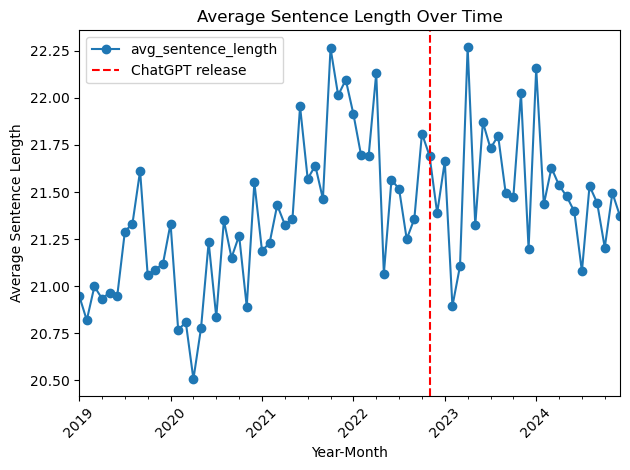

In [63]:
grouped = df_clean.groupby("year_month")["avg_sentence_length"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Average Sentence Length")
ax.set_title("Average Sentence Length Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

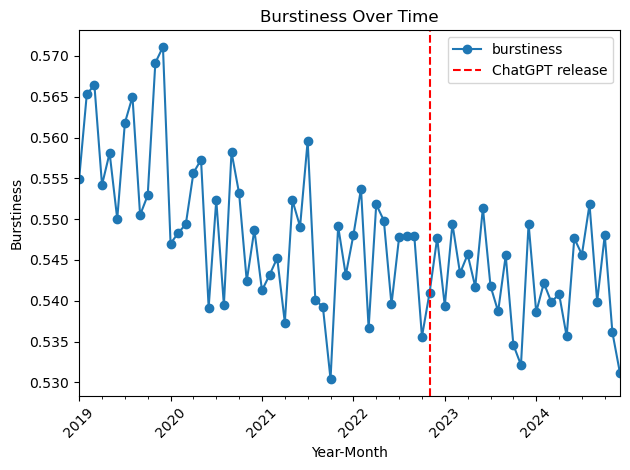

In [64]:
grouped = df_clean.groupby("year_month")["burstiness"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Burstiness")
ax.set_title("Burstiness Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

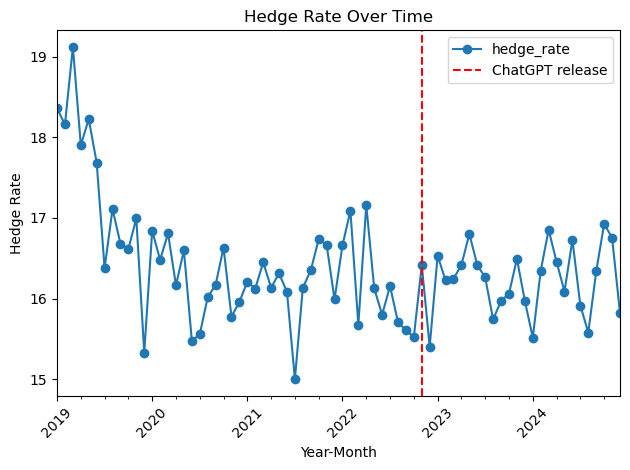

In [65]:
grouped = df_clean.groupby("year_month")["hedge_rate"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Hedge Rate")
ax.set_title("Hedge Rate Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

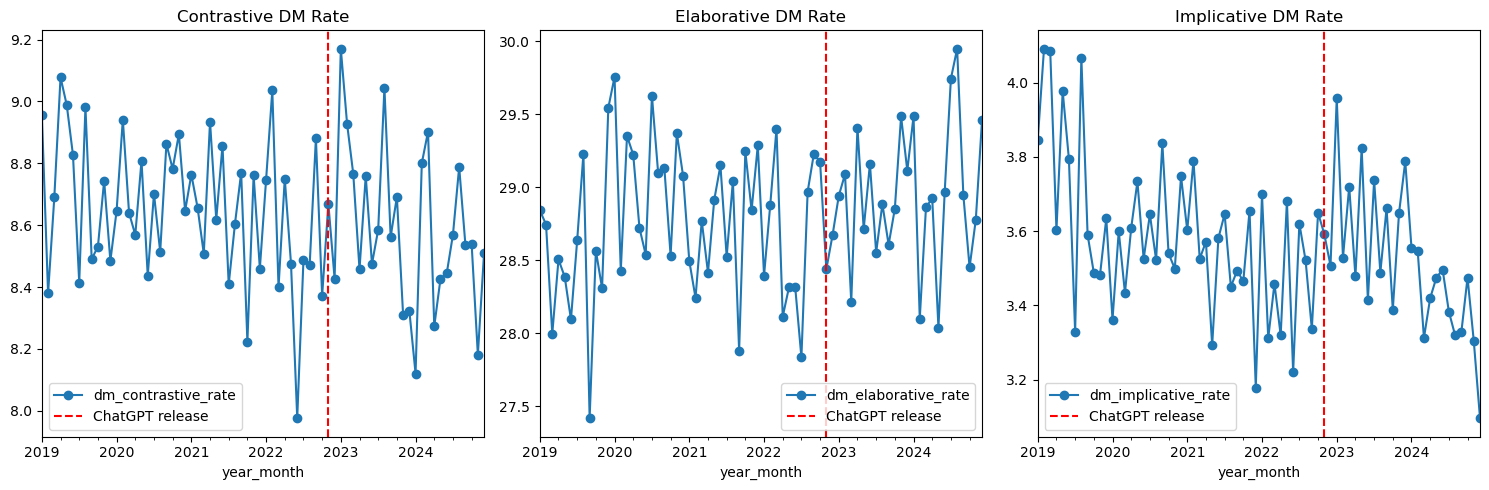

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ["dm_contrastive_rate", "dm_elaborative_rate", "dm_implicative_rate"],
    ["Contrastive DM Rate", "Elaborative DM Rate", "Implicative DM Rate"]
):
    
    df_clean.groupby("year_month")[col].mean().plot(
        marker="o", ax=ax, title=title
    )
    
    ax.axvline(
        pd.Timestamp("2022-11-01"),
        color="red",
        linestyle="--",
        label="ChatGPT release"
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

In [67]:
df_clean.to_csv("post_processing_opinion.csv", index=False)

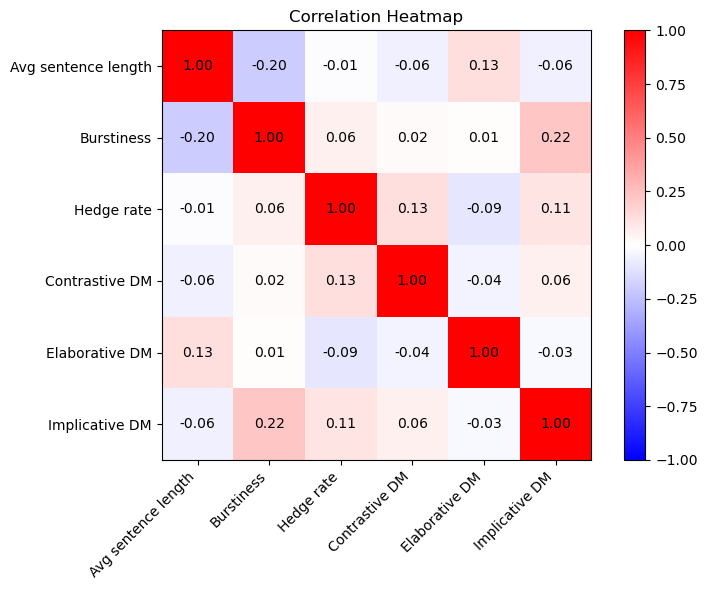

In [68]:
cols = [
    "avg_sentence_length",
    "burstiness",
    "hedge_rate",
    "dm_contrastive_rate",
    "dm_elaborative_rate",
    "dm_implicative_rate"
]

label_map = {
    "avg_sentence_length": "Avg sentence length",
    "burstiness": "Burstiness",
    "hedge_rate": "Hedge rate",
    "dm_contrastive_rate": "Contrastive DM",
    "dm_elaborative_rate": "Elaborative DM",
    "dm_implicative_rate": "Implicative DM"
}

labels = [label_map[c] for c in cols]
corr = df_clean[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    corr,
    cmap="bwr",
    vmin=-1, vmax=1
)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()